# Réplication du théorème de domination permanente de Janson

Ce notebook se concentre sur la réplication expérimentale du résultat principal étudié par Janson dans son article sur les urnes de Pólya généralisées.

Nous considérons une urne à deux couleurs : noire et blanche. Lorsqu’une boule noire est tirée, elle est replacée dans l’urne avec $m_b$ boules noires supplémentaires. Lorsqu’une boule blanche est tirée, elle est replacée avec $m_w$ boules blanches supplémentaires.

L’événement central est :

$$
A = \{B_n > W_n,\ \forall n \geq 0\}.
$$

Cet événement signifie que les boules noires restent strictement majoritaires à tout instant.

Le théorème de Janson affirme que si :

$$
m_b \geq m_w
\quad \text{et} \quad
b_0 > w_0,
$$

alors :

$$
\mathbb{P}(A) > 0.
$$

L’objectif de ce notebook n’est pas de redémontrer analytiquement le théorème, mais de reproduire expérimentalement sa prédiction qualitative par simulation de Monte Carlo.

In [1]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

from src.urn import PolyaUrn

import numpy as np
import matplotlib.pyplot as plt

# Directory for exported figures
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Utility function
def save_fig(name, ext="png"):

    plt.savefig(
        os.path.join(FIG_DIR, f"{name}.{ext}"),
        dpi=300,
        bbox_inches="tight"
    )

# Domination permanente dans les urnes de Pólya généralisées

On considère l’événement de trajectoire

$
A = \{B_n > W_n,\ \forall n \ge 0\}
$

Cet événement est une propriété de la trajectoire stochastique $(B_n, W_n)$.
Il exige que les boules noires restent strictement au-dessus des boules blanches à chaque étape observée.

Le notebook commence par une trajectoire représentative, puis passe à une estimation de la probabilité empirique de A par simulations de Monte Carlo.

### Illustration de trajectoire

Nous commençons par observer une trajectoire individuelle du processus.

Cette première expérience permet de visualiser concrètement
le mécanisme de renforcement.

Nous choisissons ici les paramètres :

- $B_0 = 10$
- $W_0 = 5$

avec :

- $m_b = 2$
- $m_w = 1$

Les boules noires possèdent donc un avantage de renforcement.

Le processus est simulé sur un horizon fini de $T = 500$ étapes.

In [2]:
urn = PolyaUrn(
    balls={"black": 10, "white": 5},
    reinforcements={"black": 2, "white": 1}
)

urn.simulate(100)

### Vérification de la domination permanente sur une trajectoire

La méthode `always_black_leading()` vérifie si la trajectoire enregistrée satisfait l’événement A à chaque étape simulée.
Il s’agit d’un test sur une trajectoire individuelle, et non d’une statistique de population.

In [3]:
urn.always_black_leading()

True

### Extraction de la trajectoire

Nous extrayons maintenant la suite des effectifs de boules noires et blanches à partir de l’historique simulé.
Les courbes obtenues représentent la trajectoire stochastique de l’urne et permettent de voir si le blanc réduit l’écart.

In [4]:
black_counts = [
    state["black"]
    for state in urn.history
]

white_counts = [
    state["white"]
    for state in urn.history
]

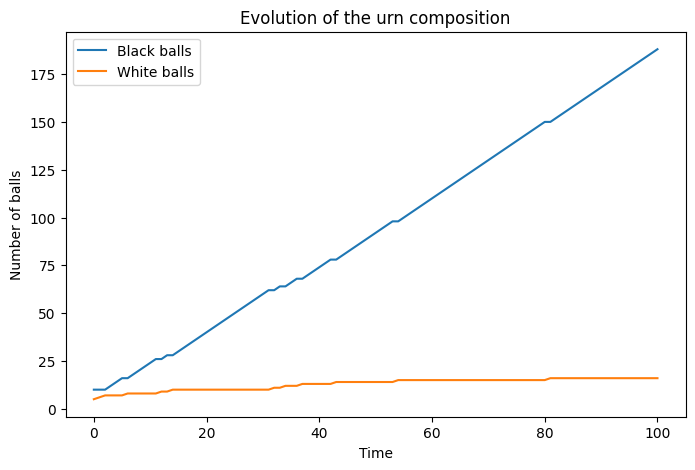

In [5]:
plt.figure(figsize=(8,5))

plt.plot(black_counts, label="Black balls")
plt.plot(white_counts, label="White balls")

plt.xlabel("Time")
plt.ylabel("Number of balls")

plt.title("Evolution of the urn composition")

plt.legend()

save_fig("urn_composition_evolution")

plt.show()

### Interprétation de la trajectoire

La trajectoire ci-dessus illustre un cas de domination soutenue des boules noires sur l’horizon simulé.

Les paramètres choisis favorisent fortement le noir :
- par l’avantage initial de composition ;
- par le mécanisme de renforcement asymétrique.

Après quelques fluctuations initiales limitées, l’écart entre les deux couleurs tend à s’amplifier progressivement sous l’effet du renforcement.

Cette trajectoire suggère qu’un renforcement asymétrique peut renforcer la domination d’une couleur sur l’horizon étudié.

Cependant, une seule réalisation ne permet pas d’évaluer précisément la probabilité de l’événement

$
A = \{B_n > W_n,\ \forall n \geq 0\}.
$

Cela motive l’utilisation de simulations de Monte Carlo afin d’estimer empiriquement la fréquence de domination permanente.

---

# Estimation expérimentale de la probabilité de domination permanente

Nous cherchons maintenant à estimer expérimentalement la probabilité
de l’événement :

$$
A = \{B_n > W_n,\ \forall n \geq 0\}.
$$

Comme cet événement porte sur un horizon infini,
nous utilisons une approximation sur un horizon fini $T$.

Une trajectoire est considérée comme un succès si :

$$
B_n > W_n
\quad
\text{pour tout }
0 \leq n \leq T.
$$

Nous répétons alors un grand nombre de simulations indépendantes
afin d’obtenir une estimation empirique de la probabilité
de domination permanente.

### Estimation par simulations de Monte Carlo

Nous approchons la probabilité de \(A\) en générant des trajectoires indépendantes avec les mêmes paramètres d’urne et en comptant la proportion de cas où le noir reste strictement dominant pendant \(T = 1000\) étapes. Cette fréquence empirique est une estimation, et elle reste sensible au nombre de simulations ainsi qu’à l’horizon fini choisi.

In [6]:
successes = 0

n_simulations = 1000
T = 1000

In [7]:
for _ in range(n_simulations):

    urn = PolyaUrn(
        balls={"black": 10, "white": 5},
        reinforcements={"black": 2, "white": 1}
    )

    urn.simulate(T)

    if urn.always_black_leading():
        successes += 1

In [8]:
estimated_probability = successes / n_simulations

print("Estimated probability of permanent domination:")
print(f"P(A) ≈ {estimated_probability:.4f}")

print(f"\nSuccessful trajectories: {successes}")
print(f"Total simulations: {n_simulations}")

Estimated probability of permanent domination:
P(A) ≈ 0.9760

Successful trajectories: 976
Total simulations: 1000


The estimated probability obtained from the simulations is consistent with the theoretical prediction of Janson’s theorem. For the chosen parameters and the finite horizon considered, the domination of black balls appears highly stable, although a small proportion of trajectories still lose dominance because of stochastic fluctuations.

---

## Conclusion

Les simulations de Monte Carlo réalisées dans ce notebook permettent de reproduire expérimentalement le phénomène central étudié par Janson dans le cadre des urnes de Pólya généralisées.

Nous avons étudié l’événement :

$$
A = \{B_n > W_n,\ \forall n \geq 0\},
$$

qui correspond à une domination permanente des boules noires au cours de l’évolution du processus.

Pour les paramètres considérés :

- \(B_0 = 10\),
- \(W_0 = 5\),
- \(m_b = 2\),
- \(m_w = 1\),

les simulations montrent qu’une proportion élevée des trajectoires conserve la domination noire jusqu’à l’horizon fini étudié \(T = 1000\).

Ce comportement est cohérent avec le théorème de Janson, qui affirme que :

$$
\mathbb P(A) > 0
$$

lorsque :

$$
m_b \geq m_w
\quad \text{et} \quad
B_0 > W_0.
$$

Les expériences mettent également en évidence le rôle important des fluctuations précoces : certaines trajectoires perdent rapidement leur avance, tandis que d’autres deviennent progressivement stables sous l’effet du renforcement asymétrique.

Il faut néanmoins rappeler que l’événement théorique est défini sur un horizon infini, alors que les simulations numériques restent limitées à un horizon fini \(T\). Les probabilités obtenues doivent donc être interprétées comme des estimations empiriques dépendant :
- du nombre de simulations réalisées ;
- de l’horizon temporel choisi ;
- et des paramètres du modèle.

Ce notebook constitue ainsi une validation expérimentale cohérente avec le théorème étudié, tout en fournissant une intuition probabiliste concrète du mécanisme de renforcement.

La suite du projet portera sur une étude plus systématique de la sensibilité des paramètres, notamment :
- l’écart initial \(B_0 - W_0\) ;
- l’asymétrie de renforcement \(m_b - m_w\) ;
- et la stabilité des trajectoires dominantes.